# I. Import Library

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import numpy as np
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from scipy.stats import kendalltau
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# SVM
from sklearn.svm import SVC

# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline


from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score, recall_score

# II. Data Loading

In [69]:
data = pd.read_csv('heart_2020_cleaned.csv')
data

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [70]:
df = data.copy()

# Data Prapretion

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

## Check Missing Value

In [72]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

Data kali ini bersih atau tidak terdapat missing value pada kolom dataset ini

## Check Column Name

In [73]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

Pengecekan apakah terdapat white space pada nama kolom

## Check Statistik Deskriptif

In [74]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
HeartDisease,319795,2,No,292422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,319795.0,NaN,NaN,NaN,28.325399,6.3561,12.02,24.03,27.34,31.42,94.85
Smoking,319795,2,No,187887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AlcoholDrinking,319795,2,No,298018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stroke,319795,2,No,307726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhysicalHealth,319795.0,NaN,NaN,NaN,3.37171,7.95085,0.0,0.0,0.0,2.0,30.0
MentalHealth,319795.0,NaN,NaN,NaN,3.898366,7.955235,0.0,0.0,0.0,3.0,30.0
DiffWalking,319795,2,No,275385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,319795,2,Female,167805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AgeCategory,319795,13,65-69,34151,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Pengecekan Column Kategorik

In [75]:
# Mengecek semua kolom numerik

cat_list = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Variables:", cat_list)

Categorical Variables: ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [76]:
df[cat_list].nunique()

HeartDisease         2
Smoking              2
AlcoholDrinking      2
Stroke               2
DiffWalking          2
Sex                  2
AgeCategory         13
Race                 6
Diabetic             4
PhysicalActivity     2
GenHealth            5
Asthma               2
KidneyDisease        2
SkinCancer           2
dtype: int64

Pengecekan hanya unique value hanya ada di kolom kategorik untuk mengetahui apakah terdapat high cardinal atau tidak.

## Pengecekan Column Numerik

In [77]:
# Mengecek semua kolom numerik
num_list = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Kolom numerik: ', num_list)

Kolom numerik:  ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']


## Check Duplicate

In [78]:
# Mengecek nilai duplikat yang ada
df.duplicated().sum()

18078

Terdapat cukup banyak duplikat pada dataset ini yaitu sebanyak 18078. Perlu ditinjau lebih jauh apa saja kolom yang terdapat duplikat. 

# EDA

## 1. Analisis BMI (Bodry Mass Index)

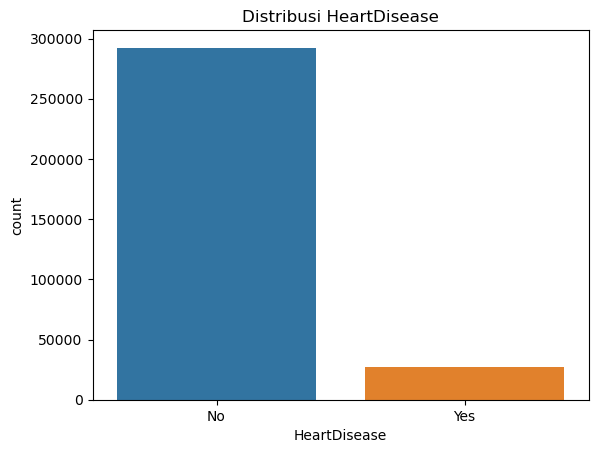

In [79]:

sns.countplot(x='HeartDisease', data=df)
plt.title('Distribusi HeartDisease')
plt.show()


## 2. Analisis Waktu Tidur (SleepTime)

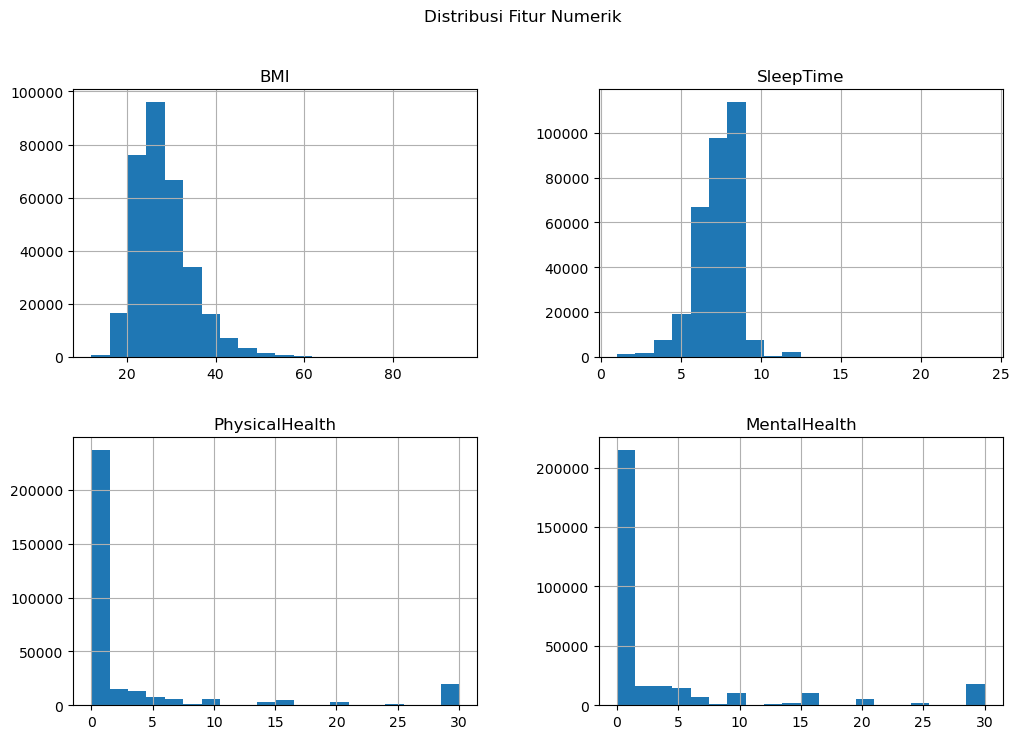

In [80]:
numerical_cols = ['BMI', 'SleepTime', 'PhysicalHealth', 'MentalHealth']
df[numerical_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribusi Fitur Numerik")
plt.show()

## 3. Korelasi antar Variabel Numerik

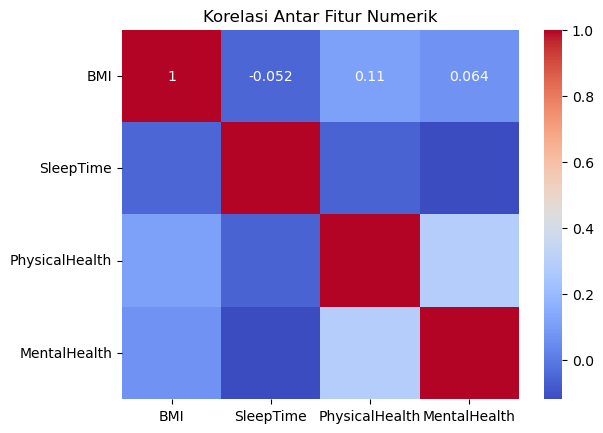

In [81]:
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

## 4. Analisis Fitur Kategorikal terhadap HeartDisease

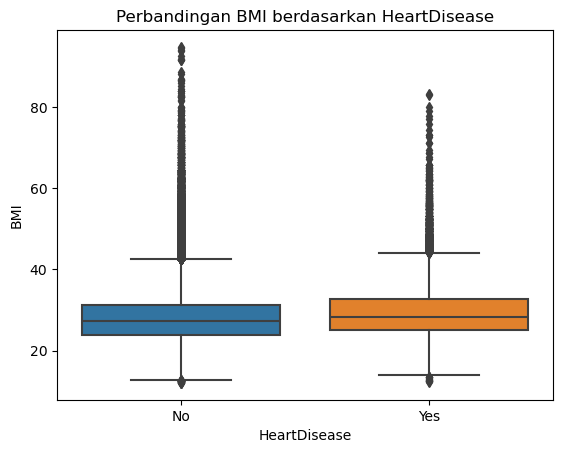

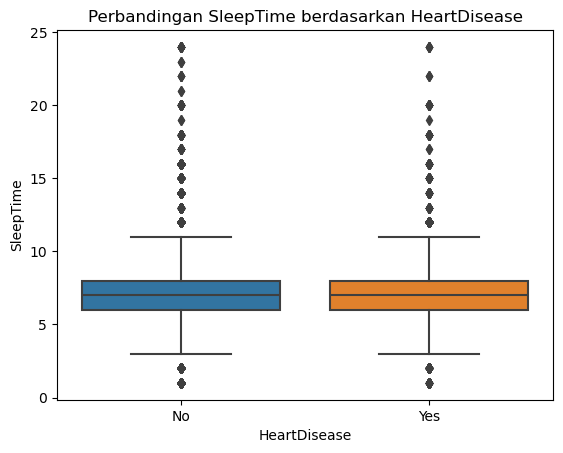

In [82]:
sns.boxplot(x='HeartDisease', y='BMI', data=df)
plt.title('Perbandingan BMI berdasarkan HeartDisease')
plt.show()

sns.boxplot(x='HeartDisease', y='SleepTime', data=df)
plt.title('Perbandingan SleepTime berdasarkan HeartDisease')
plt.show()

## 5. Analisis PhysicalHealth dan MentalHealth terhadap HeartDisease

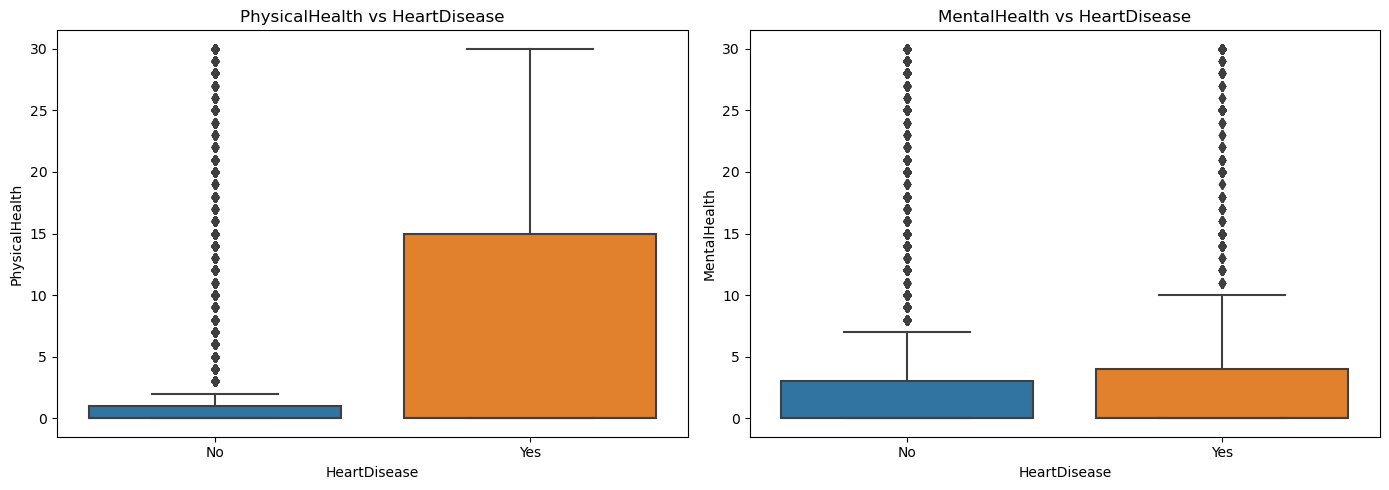

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='HeartDisease', y='PhysicalHealth', data=df, ax=axs[0])
axs[0].set_title('PhysicalHealth vs HeartDisease')

sns.boxplot(x='HeartDisease', y='MentalHealth', data=df, ax=axs[1])
axs[1].set_title('MentalHealth vs HeartDisease')

plt.tight_layout()
plt.show()

## 6.  Analisis AgeCategory dan GenHealth terhadap HeartDisease

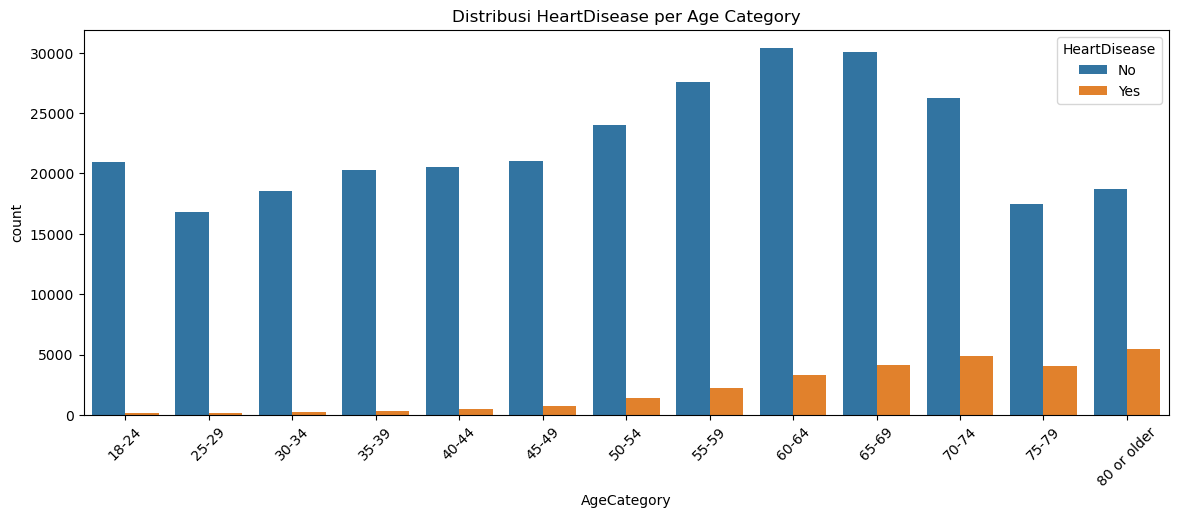

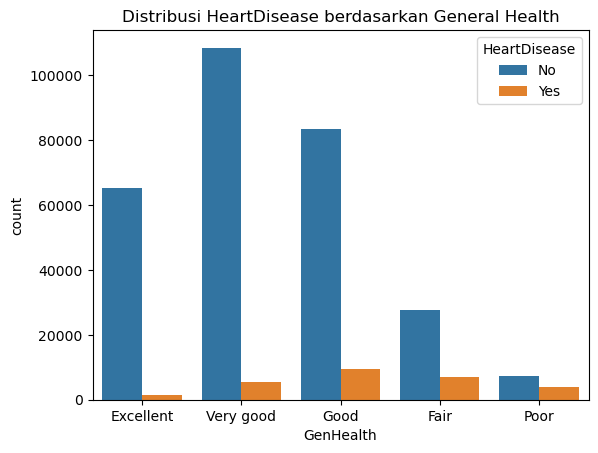

In [84]:
plt.figure(figsize=(14, 5))

# Distribusi HeartDisease per AgeCategory
sns.countplot(x='AgeCategory', hue='HeartDisease', data=df, order=sorted(df['AgeCategory'].unique()))
plt.title('Distribusi HeartDisease per Age Category')
plt.xticks(rotation=45)
plt.show()

# Distribusi HeartDisease per General Health
sns.countplot(x='GenHealth', hue='HeartDisease', data=df,
              order=['Excellent', 'Very good', 'Good', 'Fair', 'Poor'])
plt.title('Distribusi HeartDisease berdasarkan General Health')
plt.show()


## 7. Hubungan antara SleepTime dan HeartDisease

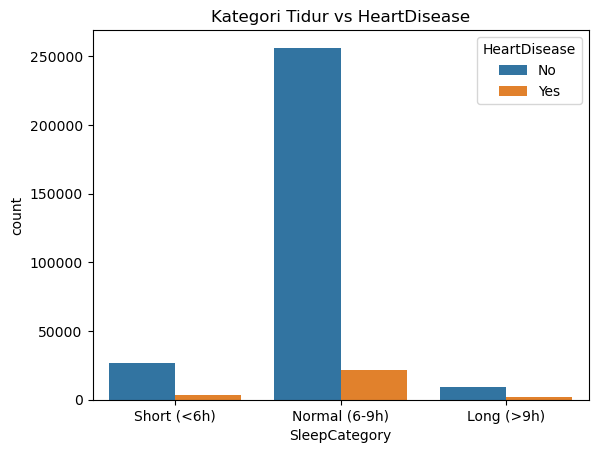

In [85]:
# Buat kategori durasi tidur
def sleep_category(hours):
    if hours < 6:
        return 'Short (<6h)'
    elif hours <= 9:
        return 'Normal (6-9h)'
    else:
        return 'Long (>9h)'

df['SleepCategory'] = df['SleepTime'].apply(sleep_category)

# Visualisasi distribusi HeartDisease berdasarkan kategori tidur
sns.countplot(x='SleepCategory', hue='HeartDisease', data=df)
plt.title('Kategori Tidur vs HeartDisease')
plt.show()


# Feature Engineering

## Sampling Data

In [86]:
df_sampled = df.sample(frac=0.03, random_state=42)  # 3% data

## a. Handling Cadinality 

In [87]:
df_sampled.nunique()

HeartDisease           2
BMI                 1452
Smoking                2
AlcoholDrinking        2
Stroke                 2
PhysicalHealth        31
MentalHealth          30
DiffWalking            2
Sex                    2
AgeCategory           13
Race                   6
Diabetic               4
PhysicalActivity       2
GenHealth              5
SleepTime             19
Asthma                 2
KidneyDisease          2
SkinCancer             2
SleepCategory          3
dtype: int64

BMI merupakan kolom yang memiliki high cardinal. namun, hal ini masuk akal karena BMI merupakan Body Mass Index yang merupakan perkiraan lemak tubuh yang didasarkan pada tinggi dan berat badan. Dengan melakukan perhitungan BMI, Anda dapat memperkirakan apakah berat badan yang dimiliki sudah tergolong normal, kurus (underweight), atau obesitas (overweight). Sehingga sangat masuk akal jika memiliki banyak cardinality karena setiap manusia memiliki BMI yang bervariasi.

In [88]:
df_sampled[cat_list].nunique()

HeartDisease         2
Smoking              2
AlcoholDrinking      2
Stroke               2
DiffWalking          2
Sex                  2
AgeCategory         13
Race                 6
Diabetic             4
PhysicalActivity     2
GenHealth            5
Asthma               2
KidneyDisease        2
SkinCancer           2
dtype: int64

## b. Handling Duplicate

In [89]:
df_sampled.duplicated().sum()


28

## c. Split Train dan Test

In [90]:
# Split Feature dengan Target

x = df_sampled.drop(['HeartDisease'], axis=1)
y = df_sampled['HeartDisease'].map({'No' : 0, 'Yes' : 1})

In [91]:
# x = df_sampled.drop(columns='HeartDisease')
# y = df_sampled['HeartDisease']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [92]:
cat_cols = x_train.select_dtypes(include=['object']).columns.tolist()
print("Categorical Variables:", cat_cols)

Categorical Variables: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer', 'SleepCategory']


In [93]:
# Split antara Train dengan Test

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

print('Train size : ', x_train.shape)
print('Test size  : ', x_test.shape)

Train size :  (7675, 18)
Test size  :  (1919, 18)


## d. Handling Missing Value

In [94]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
SleepCategory       0
dtype: int64

Tidak terdapat missing value sehingga tidak perlu di handling

## e. Handling Outlier

In [95]:
x_train[num_list].skew()

BMI               1.440362
PhysicalHealth    2.492939
MentalHealth      2.320711
SleepTime         0.888413
dtype: float64

Terdapat beberapa kolom yang skewnya cukup tinggi.

In [96]:
#check distribution form skewness
num_cols = list(x_train.select_dtypes(exclude='object').columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(x_train[col].skew(),1), np.where(
    (round(x_train[col].skew(),1) <= 0.5) & (round(x_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])



skewness = pd.DataFrame(columns=['nama kolom', 'nilai skewness', 'distribution'], data= listItem)
skewness

,nama kolom,nilai skewness,distribution
0,BMI,1.4,skewed
1,PhysicalHealth,2.5,skewed
2,MentalHealth,2.3,skewed
3,SleepTime,0.9,skewed


## f. Feature Selection

In [97]:
kendall_cols = []
kendall_interpretasi = []

for col in x_train:
    coef, pval = kendalltau(x_train[col], y_train)
    kendall_cols.append(col)
    if pval < 0.05:
        kendall_interpretasi.append('ada korelasi')
    else:
        kendall_interpretasi.append('tidak ada korelasi')

kendall_df = pd.DataFrame({
    'nama kolom': kendall_cols,
    'hasil': kendall_interpretasi
})

kendall_df

,nama kolom,hasil
0,BMI,ada korelasi
1,Smoking,ada korelasi
2,AlcoholDrinking,tidak ada korelasi
3,Stroke,ada korelasi
4,PhysicalHealth,ada korelasi
5,MentalHealth,tidak ada korelasi
6,DiffWalking,ada korelasi
7,Sex,ada korelasi
8,AgeCategory,ada korelasi
9,Race,ada korelasi


In [98]:
cat_cols = ['Smoking','Stroke','DiffWalking','Sex','AgeCategory','Race','Diabetic','PhysicalActivity','GenHealth','Asthma','KidneyDisease','SkinCancer']
num_cols = ['BMI', 'PhysicalHealth']

## e. Column Transformer

In [99]:
# Membuat column Transformer

transformer = ColumnTransformer([
    # ('Num Cols', StandardScaler(), num_cols),
    # ('Cat Cols', OneHotEncoder(), cat_cols)
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])


# Modeling I

## Model Definisition

In [100]:

#Making pipeline for LogReg
pipe_SVM = Pipeline([
('transformer', transformer),
('classifier', SVC())
])

#Making pipeline for Decision Tree
pipe_KNN = Pipeline([
('transformer', transformer),
('classifier', KNeighborsClassifier())
])

#Making pipeline for Random Forest
pipe_DT = Pipeline([
('transformer', transformer),
('classifier', DecisionTreeClassifier())
])

#Making pipeline for XGBoost
pipe_RF = Pipeline([
('transformer', transformer),
('classifier',RandomForestClassifier())
])

#Making pipeline for XGBoost
pipe_xgb = Pipeline([
('transformer', transformer),
('classifier', XGBClassifier())
])

## SVM

In [101]:
pipe_SVM

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Smoking', 'Stroke',
                                                   'DiffWalking', 'Sex',
                                                   'AgeCategory', 'Race',
                                                   'Diabetic',
                                                   'PhysicalActivity',
                                                   'GenHealth', 'Asthma',
                                                   'KidneyDisease',
                                                   'SkinCancer']),
                                                 ('num', StandardScaler(),
                                                  ['BMI', 'PhysicalHealth'])])),
                ('classifier', SVC())])

In [102]:
pipe_SVM.fit(x_train, y_train)
print('Training Score: ',round(pipe_SVM.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_SVM.score(x_test, y_test),4))

Training Score:  0.9096
Testing Score:  0.9078


In [103]:
y_SVM_pred = pipe_SVM.predict(x_test)
y_SVM_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [104]:
target = ['HeartDisease', 'non HeartDisease']
print(classification_report(y_test, y_SVM_pred, target_names = target))

                  precision    recall  f1-score   support

    HeartDisease       0.91      1.00      0.95      1742
non HeartDisease       0.00      0.00      0.00       177

        accuracy                           0.91      1919
       macro avg       0.45      0.50      0.48      1919
    weighted avg       0.82      0.91      0.86      1919



c:\Users\anand\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [105]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_SVM,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.         0.         0.01408451 0.01408451 0.        ]
F1 Score - Mean - Cross Validation :  0.005633802816901409
F1 Score - Std - Cross Validation  :  0.006899971106431487
F1 Score - Range of Test-Set       :  -0.0012661682895300785 - 0.012533773923332896


In [106]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_SVM, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.694
Nilai Standard Deviasi Cross Validation: 0.032


roc-auc itu buat tau modelnya bisa membedakan yg 0 dan 1 atau tidak. cross validation buat liat selama training dia modelnya gimana.

## KNN

In [107]:
pipe_KNN.fit(x_train, y_train)
print('Training Score: ',round(pipe_KNN.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_KNN.score(x_test, y_test),4))

Training Score:  0.918
Testing Score:  0.9052


In [108]:
y_KNN_pred = pipe_KNN.predict(x_test)
y_KNN_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [109]:
target = ['HeartDisease', 'non HeartDisease']
print(classification_report(y_test, y_KNN_pred, target_names = target))

                  precision    recall  f1-score   support

    HeartDisease       0.91      0.99      0.95      1742
non HeartDisease       0.39      0.05      0.09       177

        accuracy                           0.91      1919
       macro avg       0.65      0.52      0.52      1919
    weighted avg       0.86      0.91      0.87      1919



In [110]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_KNN,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.11111111 0.11627907 0.09638554 0.08484848 0.09090909]
F1 Score - Mean - Cross Validation :  0.09990665976096069
F1 Score - Std - Cross Validation  :  0.01194737364876291
F1 Score - Range of Test-Set       :  0.08795928611219778 - 0.11185403340972361


In [111]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_KNN, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.661
Nilai Standard Deviasi Cross Validation: 0.031


## Decision Tree

In [112]:
pipe_DT.fit(x_train, y_train)
print('Training Score: ',round(pipe_DT.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_DT.score(x_test, y_test),4))

Training Score:  0.9988
Testing Score:  0.8593


In [113]:
y_DT_pred = pipe_DT.predict(x_test)
y_DT_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [114]:
target = ['HeartDisease', 'non HeartDisease']
print(classification_report(y_test, y_DT_pred, target_names = target))

                  precision    recall  f1-score   support

    HeartDisease       0.93      0.92      0.92      1742
non HeartDisease       0.25      0.27      0.26       177

        accuracy                           0.86      1919
       macro avg       0.59      0.60      0.59      1919
    weighted avg       0.86      0.86      0.86      1919



In [115]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_DT,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.22695035 0.22666667 0.2        0.21153846 0.22712934]
F1 Score - Mean - Cross Validation :  0.2184569640708979
F1 Score - Std - Cross Validation  :  0.010984281143005743
F1 Score - Range of Test-Set       :  0.20747268292789217 - 0.22944124521390363


In [116]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_DT, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.570
Nilai Standard Deviasi Cross Validation: 0.007


## Random Forest

In [117]:
pipe_RF.fit(x_train, y_train)
print('Training Score: ',round(pipe_RF.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_RF.score(x_test, y_test),4))

Training Score:  0.9988
Testing Score:  0.9015


In [118]:
y_RF_pred = pipe_RF.predict(x_test)
y_RF_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [119]:
target = ['HeartDisease', 'non HeartDisease']
print(classification_report(y_test, y_RF_pred, target_names = target))

                  precision    recall  f1-score   support

    HeartDisease       0.92      0.98      0.95      1742
non HeartDisease       0.38      0.11      0.17       177

        accuracy                           0.90      1919
       macro avg       0.65      0.55      0.56      1919
    weighted avg       0.87      0.90      0.88      1919



In [120]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_RF,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.10588235 0.11173184 0.08235294 0.10416667 0.11518325]
F1 Score - Mean - Cross Validation :  0.10386341008660623
F1 Score - Std - Cross Validation  :  0.011462279876802556
F1 Score - Range of Test-Set       :  0.09240113020980367 - 0.11532568996340878


In [121]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_RF, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.760
Nilai Standard Deviasi Cross Validation: 0.022


## Boost

In [122]:
pipe_xgb.fit(x_train, y_train)
print('Training Score: ',round(pipe_xgb.score(x_train, y_train),4))
print('Testing Score: ', round(pipe_xgb.score(x_test, y_test),4))

Training Score:  0.9599
Testing Score:  0.9052


In [123]:
y_xgb_pred = pipe_xgb.predict(x_test)
y_xgb_pred

array([0, 0, 0, ..., 0, 0, 0])

In [124]:
target = ['HeartDisease', 'non HeartDisease']
print(classification_report(y_test, y_xgb_pred, target_names = target))

                  precision    recall  f1-score   support

    HeartDisease       0.92      0.98      0.95      1742
non HeartDisease       0.46      0.15      0.23       177

        accuracy                           0.91      1919
       macro avg       0.69      0.57      0.59      1919
    weighted avg       0.88      0.91      0.88      1919



In [125]:
#Cross Validation

f1_train_cross_val = cross_val_score(pipe_xgb,
                                     x_train,
                                     y_train,
                                     cv=5,
                                     scoring="f1")

print('F1 Score - All - Cross Validation  : ', f1_train_cross_val)
print('F1 Score - Mean - Cross Validation : ', f1_train_cross_val.mean())
print('F1 Score - Std - Cross Validation  : ', f1_train_cross_val.std())
print('F1 Score - Range of Test-Set       : ', (f1_train_cross_val.mean()-f1_train_cross_val.std()) , '-', (f1_train_cross_val.mean()+f1_train_cross_val.std()))

F1 Score - All - Cross Validation  :  [0.19895288 0.2244898  0.15873016 0.14358974 0.21621622]
F1 Score - Mean - Cross Validation :  0.18839575880712753
F1 Score - Std - Cross Validation  :  0.03186169170669663
F1 Score - Range of Test-Set       :  0.15653406710043088 - 0.22025745051382417


In [126]:
# Menghitung nilai CV sebelum tuning
cv_scores = cross_val_score(pipe_xgb, x_train, y_train, cv=5, scoring='roc_auc')
print(f'Nilai Mean Cross Validation: {cv_scores.mean():.3f}')
print(f'Nilai Standard Deviasi Cross Validation: {cv_scores.std():.3f}')

Nilai Mean Cross Validation: 0.782
Nilai Standard Deviasi Cross Validation: 0.020


# Model Comparison

In [127]:
models = {
    'SVM'           : pipe_SVM,
    'KNN'           : pipe_KNN,
    'Decision Tree' : pipe_DT,
    'Random Forest' : pipe_RF,
    'XGBoost' : pipe_xgb
}

metrics = {
    'Accuracy' : accuracy_score,
    'F1-Score' : f1_score,
    'Recall' : recall_score,
}

df_model = pd.DataFrame(columns = models.keys(), index=['Accuracy', 'F1-Score', 'Recall'])

for metric in metrics.keys():
  for model in models.keys():
    df_model.loc[metric, model] = metrics[metric](y_test, models[model].predict(x_test))

In [128]:
df_model

,SVM,KNN,Decision Tree,Random Forest,XGBoost
Accuracy,0.907764,0.905159,0.859302,0.901511,0.905159
F1-Score,0.0,0.09,0.262295,0.174672,0.228814
Recall,0.0,0.050847,0.271186,0.112994,0.152542


Decision Tree: 0.259 ✅

In [129]:
models = {
    'SVM'           : pipe_SVM,
    'KNN'           : pipe_KNN,
    'Decision Tree' : pipe_DT,
    'Random Forest' : pipe_RF,
    'XGBoost' : pipe_xgb
}

metrics = {
    'Mean' : cross_val_score(models[model], x_train, y_train, cv = 5, scoring='f1').mean(),
    'Std' : cross_val_score(models[model], x_train, y_train, cv = 5, scoring='f1').std()
}

df_cross_val = pd.DataFrame(columns = models.keys(), index = ['Mean', 'Std'])

for i in metrics.keys():
  for j in models.keys():
    df_cross_val.loc[i, j] = metrics[i]

In [130]:
df_cross_val

,SVM,KNN,Decision Tree,Random Forest,XGBoost
Mean,0.188396,0.188396,0.188396,0.188396,0.188396
Std,0.031862,0.031862,0.031862,0.031862,0.031862


In [131]:
models = {
    'SVM'           : pipe_SVM,
    'KNN'           : pipe_KNN,
    'Decision Tree' : pipe_DT,
    'Random Forest' : pipe_RF,
    'XGBoost'       : pipe_xgb
}

# Buat DataFrame kosong untuk menyimpan hasil ROC-AUC
df_roc_auc = pd.DataFrame(columns=models.keys(), index=['Mean', 'Std'])

# Hitung ROC-AUC cross validation untuk setiap model
for model_name, model_pipeline in models.items():
    roc_auc_scores = cross_val_score(model_pipeline, x_train, y_train, cv=5, scoring='roc_auc')
    df_roc_auc.loc['Mean', model_name] = roc_auc_scores.mean()
    df_roc_auc.loc['Std', model_name] = roc_auc_scores.std()

# Konversi nilai ke float dan bulatkan 3 desimal
df_roc_auc = df_roc_auc.astype(float).round(3)

# Tampilkan hasil
print(df_roc_auc)

        SVM    KNN  Decision Tree  Random Forest  XGBoost
Mean  0.694  0.661          0.570          0.762    0.782
Std   0.032  0.031          0.009          0.023    0.020


In [132]:
y_train.value_counts()

HeartDisease
0    6976
1     699
Name: count, dtype: int64

# Modeling II

In [136]:
##Parameter Tuning
param_grid_DT = {
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

grid_DT = GridSearchCV(
    estimator=pipe_DT,
    param_grid=param_grid_DT,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_DT.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Smoking',
                                                                          'Stroke',
                                                                          'DiffWalking',
                                                                          'Sex',
                                                                          'AgeCategory',
                                                                          'Race',
                                                                          'Diabetic',
                                                                          'PhysicalActivity',
                                                                          'GenHealth',
                                                                          'Asthma',
                                                                          'KidneyDisease',
                                                                          'SkinCancer']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['BMI',
                                                                          'PhysicalHealth'])])),
                                       ('classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 10, None],
                         'classifier__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [137]:
print("Best parameters:", grid_DT.best_params_)
print("Best score (CV accuracy):", grid_DT.best_score_)

Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Best score (CV accuracy): 0.9077524429967425


## mode evaluation after tuning

In [139]:
models = {
    'Random Forest' : grid_DT
}

metrics = {
    'Accuracy' : accuracy_score,
    'F1-Score' : f1_score,
}

model_tuning = pd.DataFrame(columns = models.keys(), index=['Accuracy', 'F1-Score'])

for metric in metrics.keys():
  for model in models.keys():
    model_tuning.loc[metric, model] = metrics[metric](y_test, models[model].predict(x_test))

In [140]:
print(classification_report(y_test, grid_DT.predict(x_test)))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1742
           1       0.00      0.00      0.00       177

    accuracy                           0.91      1919
   macro avg       0.45      0.50      0.48      1919
weighted avg       0.82      0.91      0.86      1919



c:\Users\anand\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\anand\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
